# 08 — Model Explainability (SHAP)

**Day 2, Step 8.** "Employee 101 — 82% attrition risk" is useless to an HR
person without "why".

Two production details the Build Notes' snippet does not cover:

* **Which model to explain.** The deployed model is calibrated, and calibration
  is a monotonic transform: it changes the number, not which features drove it.
  SHAP therefore runs against the uncalibrated base pipeline.
* **One-hot columns are summed back onto their source feature**, so a reader
  sees "OverTime" once rather than "OverTime: Yes" and "OverTime: No" competing.

In [1]:
import sys, warnings
sys.path.insert(0, "../src"); sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# The lab imports from the factory. Nothing below reimplements pipeline logic.
from hrai.utils.config import get, raw_path, seed
from hrai.utils.io import load_raw, load_processed
from hrai.utils.logger import setup_logging
setup_logging(fmt="human")
print(f"seed={seed()}  |  datasets: {sorted(get('datasets'))}")

seed=42  |  datasets: ['employee_attrition', 'essential_skills', 'hr_performance_engagement', 'occupation_data', 'software_skills']


In [2]:
from hrai.ml.explain import get_explainer

df = load_processed("employee_attrition_processed")
explainer = get_explainer()
importance = pd.DataFrame(explainer.global_importance(df, top_n=15))
importance

2026-08-28 01:54:54 | INFO  | using LinearExplainer


,feature,label,importance,direction_correlation,is_categorical,direction
0,JobRole,JobRole,0.93970,0.0524,True,varies by category
1,OverTime,OverTime,0.72546,-0.0806,True,varies by category
2,TenureInRoleRatio,TenureInRoleRatio,0.53987,-1.0000,False,higher value reduces risk
3,YearsAtCompany,YearsAtCompany,0.51688,-1.0000,False,higher value reduces risk
4,YearsInCurrentRole,YearsInCurrentRole,0.46724,1.0000,False,higher value increases risk
5,BusinessTravel,BusinessTravel,0.44794,0.3151,True,varies by category
6,TotalWorkingYears,TotalWorkingYears,0.44203,-1.0000,False,higher value reduces risk
7,MaritalStatus,MaritalStatus,0.42990,-0.0442,True,varies by category
8,NumCompaniesWorked,NumCompaniesWorked,0.42538,1.0000,False,higher value increases risk
9,EducationField,EducationField,0.35878,-0.5240,True,varies by category


### Direction comes from correlation, not mean signed SHAP

Mean signed SHAP is ~0 for every feature by construction — SHAP values are
centred. Using it produces confident, meaningless directions. Direction here is
the correlation between a feature's value and its SHAP value; categorical
features are labelled "varies by category", because a category has no "higher
value".

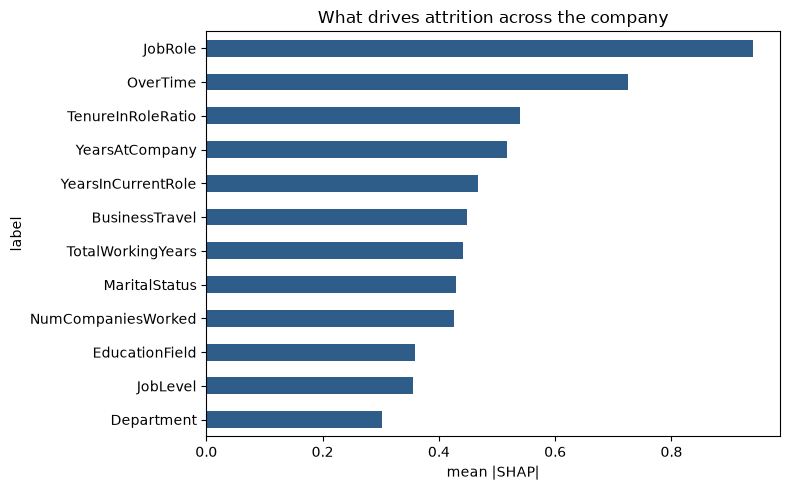

In [3]:
ax = importance.head(12).set_index("label")["importance"].iloc[::-1].plot(
    kind="barh", figsize=(8, 5), color="#2F5D8A",
    title="What drives attrition across the company")
ax.set_xlabel("mean |SHAP|"); plt.tight_layout()

## Local — why *this* person is flagged

In [4]:
for idx in [0, 1]:
    row = df.iloc[[idx]]
    left = "left" if row.iloc[0]["attrition_flag"] else "stayed"
    print(f"Employee A-{int(row.iloc[0]['employee_id'])}  (actually {left})")
    for c in explainer.explain_row(row, top_n=5):
        print(f"   {c.label:26} = {str(c.value):20} shap={c.shap_value:+.4f}  {c.direction}")
    print()

Employee A-1  (actually left)
   OverTime                   = Yes                  shap=+1.1121  increases risk
   NumCompaniesWorked         = 8                    shap=+1.0999  increases risk
   WorkLifeBalance            = 1                    shap=+0.6047  increases risk
   MaritalStatus              = Single               shap=+0.4795  increases risk
   Department                 = Sales                shap=+0.4267  increases risk

Employee A-2  (actually stayed)
   BusinessTravel             = Travel_Frequently    shap=+0.6561  increases risk
   OverTime                   = No                   shap=-0.5729  reduces risk
   PercentSalaryHike          = 23                   shap=-0.5328  reduces risk
   YearsInCurrentRole         = 7                    shap=+0.4218  increases risk
   TenureInRoleRatio          = 0.6364               shap=-0.3546  reduces risk

